# Trendyol E-Ticaret Yarışması 2026 — Kapsamlı Veri Analizi

**Amaç:** Veriyi derinlemesine anlamak, negatif örnekleme stratejisi seçmek ve özellik mühendisliği için zemin oluşturmak.

**Problem özeti:** Verilen bir `(arama_terimi, ürün)` çifti için ürünün arama temiyle **alakalı (1)** ya da **alakasız (0)** olduğunu tahmin et.  
Eğitim verisi **yalnızca pozitif** çiftlerden oluşur. Test setinde negatifler de vardır.

**Metrik:** Macro-averaged F1 (her iki sınıfa eşit ağırlık)

---
> Bu notebook Kaggle ortamında çalıştırılmak üzere yazılmıştır.

## 0. Kurulum & Yardımcı Fonksiyonlar

In [1]:
import pandas as pd
import numpy as np
import re
import os
import ast
from collections import Counter, defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

matplotlib.rcParams['figure.figsize'] = (14, 5)
matplotlib.rcParams['font.size'] = 12
sns.set_style('whitegrid')
PALETTE = sns.color_palette('tab10')

# ── Yollar ──────────────────────────────────────────────────────────
DATA_DIR = Path(r'C:\Users\Asus\Desktop\projeler egit\TEKNOFEST_TRENDYOL\trendyol-e-ticaret-yarismasi-2026-kaggle')
OUT_DIR  = Path(r'C:\Users\Asus\Desktop\projeler egit\TEKNOFEST_TRENDYOL\claude only\figures')
OUT_DIR.mkdir(exist_ok=True)

# ── Türkçe normalizer ────────────────────────────────────────────────
_TOKEN_RE = re.compile(r"[^0-9a-zçğıöşü]+")

def norm_tr(s: str) -> str:
    if not isinstance(s, str): return ''
    s = s.replace('İ', 'i').replace('I', 'ı').replace('i̇', 'i')
    return s.lower()

def tokenize(s: str, min_len: int = 2) -> list:
    return [t for t in _TOKEN_RE.split(norm_tr(s)) if len(t) >= min_len]

def parse_attributes(attr_str: str) -> dict:
    if not isinstance(attr_str, str) or not attr_str.strip():
        return {}
    result = {}
    parts = attr_str.split(',')
    for part in parts:
        if ':' in part:
            k, _, v = part.partition(':')
            result[k.strip().lower()] = v.strip().lower()
    return result

print('✓ Kütüphaneler yüklendi')
print(f'✓ DATA_DIR: {DATA_DIR}')
print(f'✓ OUT_DIR : {OUT_DIR}')
print(f'✓ Veri klasörü mevcut: {DATA_DIR.exists()}')

✓ Kütüphaneler yüklendi
✓ DATA_DIR: C:\Users\Asus\Desktop\projeler egit\TEKNOFEST_TRENDYOL\trendyol-e-ticaret-yarismasi-2026-kaggle
✓ OUT_DIR : C:\Users\Asus\Desktop\projeler egit\TEKNOFEST_TRENDYOL\claude only\figures
✓ Veri klasörü mevcut: True


In [2]:
# Eğer üstteki hücreyi çalıştırdıktan sonra hâlâ hata alıyorsan buradan düzelt:
from pathlib import Path
DATA_DIR = Path(r'C:\Users\Asus\Desktop\projeler egit\TEKNOFEST_TRENDYOL\trendyol-e-ticaret-yarismasi-2026-kaggle')
OUT_DIR  = Path(r'C:\Users\Asus\Desktop\projeler egit\TEKNOFEST_TRENDYOL\claude only\figures')
OUT_DIR.mkdir(exist_ok=True)
print('DATA_DIR:', DATA_DIR)
print('Mevcut mu:', DATA_DIR.exists())
import os; print('Dosyalar:', os.listdir(DATA_DIR))

DATA_DIR: C:\Users\Asus\Desktop\projeler egit\TEKNOFEST_TRENDYOL\trendyol-e-ticaret-yarismasi-2026-kaggle
Mevcut mu: True
Dosyalar: ['items.csv', 'sample_submission.csv', 'submission_pairs.csv', 'terms.csv', 'training_pairs.csv']


## 1. Veri Yükleme

In [3]:
items    = pd.read_csv(DATA_DIR / 'items.csv')
terms    = pd.read_csv(DATA_DIR / 'terms.csv')
train    = pd.read_csv(DATA_DIR / 'training_pairs.csv')
test     = pd.read_csv(DATA_DIR / 'submission_pairs.csv')
sample   = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'items    : {items.shape[0]:>10,} satır × {items.shape[1]} sütun')
print(f'terms    : {terms.shape[0]:>10,} satır × {terms.shape[1]} sütun')
print(f'train    : {train.shape[0]:>10,} satır × {train.shape[1]} sütun')
print(f'test     : {test.shape[0]:>10,} satır × {test.shape[1]} sütun')
print(f'sample   : {sample.shape[0]:>10,} satır × {sample.shape[1]} sütun')

items    :    962,873 satır × 7 sütun
terms    :     50,153 satır × 2 sütun
train    :    250,000 satır × 4 sütun
test     :  3,359,679 satır × 3 sütun
sample   :  3,359,679 satır × 2 sütun


## 2. Genel Veri Kalitesi

In [4]:
def missing_report(df, name):
    miss = df.isnull().sum()
    pct  = miss / len(df) * 100
    report = pd.DataFrame({'eksik_sayi': miss, 'eksik_pct': pct.round(2)})
    report = report[report['eksik_sayi'] > 0]
    if report.empty:
        print(f'[{name}] → Eksik değer yok ✓')
    else:
        print(f'[{name}] Eksik değerler:')
        display(report)

for df, name in [(items, 'items'), (terms, 'terms'), (train, 'train'), (test, 'test')]:
    missing_report(df, name)

[items] Eksik değerler:


,eksik_sayi,eksik_pct
brand,2,0.0


[terms] → Eksik değer yok ✓
[train] → Eksik değer yok ✓
[test] → Eksik değer yok ✓


In [5]:
# items — unknown değerler (eksik değil ama anlamlı mı?)
print('=== items.csv — Kategorik Dağılımlar ===')
for col in ['gender', 'age_group']:
    vc = items[col].fillna('NaN').value_counts()
    pct = vc / len(items) * 100
    print(f"\n{col}:")
    for val, cnt in vc.items():
        print(f"  {val:<20} {cnt:>8,}  ({pct[val]:.1f}%)")

=== items.csv — Kategorik Dağılımlar ===

gender:
  unknown               590,714  (61.3%)
  kadın                 192,045  (19.9%)
  erkek                  99,433  (10.3%)
  unisex                 80,681  (8.4%)

age_group:
  unknown               572,028  (59.4%)
  yetişkin              280,876  (29.2%)
  çocuk                  52,876  (5.5%)
  genç                   31,246  (3.2%)
  bebek                  18,426  (1.9%)
  bebek & çocuk           7,421  (0.8%)


## 3. Arama Terimleri (Terms / Queries) Analizi

       token_count  char_count
count     50153.00    50153.00
mean          2.58       16.18
std           0.98        6.66
min           0.00        2.00
25%           2.00       12.00
50%           2.00       15.00
75%           3.00       20.00
max           8.00       54.00


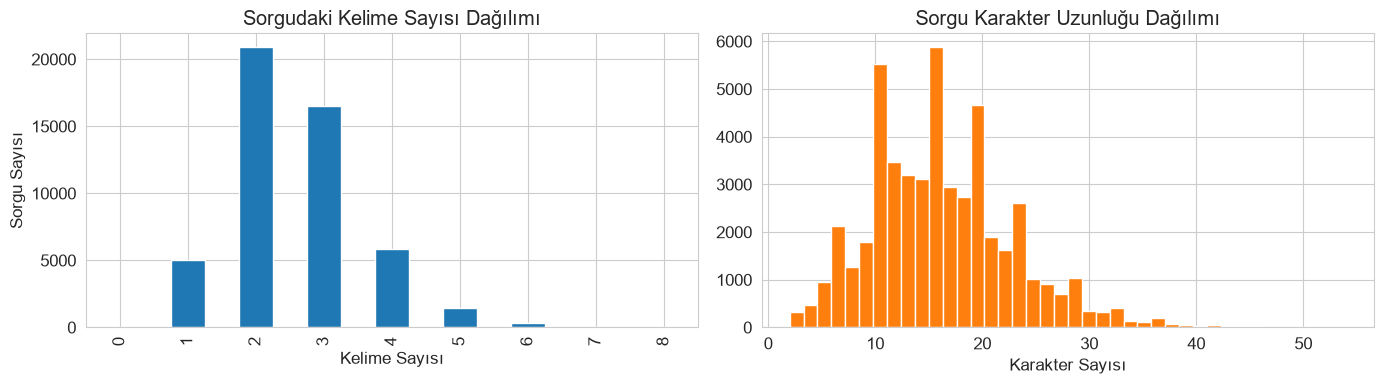


En kısa sorgu : "hp" (2 karakter)
En uzun sorgu  : "bilge ilaç matcha premium japanese diğer bitki çayları..." (54 karakter)


In [6]:
terms['query_norm']      = terms['query'].apply(norm_tr)
terms['tokens']          = terms['query_norm'].apply(tokenize)
terms['token_count']     = terms['tokens'].apply(len)
terms['char_count']      = terms['query_norm'].apply(len)

print(terms[['query', 'token_count', 'char_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
terms['token_count'].clip(upper=10).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=PALETTE[0])
axes[0].set_title('Sorgudaki Kelime Sayısı Dağılımı')
axes[0].set_xlabel('Kelime Sayısı')
axes[0].set_ylabel('Sorgu Sayısı')

terms['char_count'].clip(upper=60).hist(bins=40, ax=axes[1], color=PALETTE[1], edgecolor='white')
axes[1].set_title('Sorgu Karakter Uzunluğu Dağılımı')
axes[1].set_xlabel('Karakter Sayısı')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_query_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nEn kısa sorgu : "{terms.loc[terms["char_count"].idxmin(), "query"]}" ({terms["char_count"].min()} karakter)')
print(f'En uzun sorgu  : "{terms.loc[terms["char_count"].idxmax(), "query"][:80]}..." ({terms["char_count"].max()} karakter)')

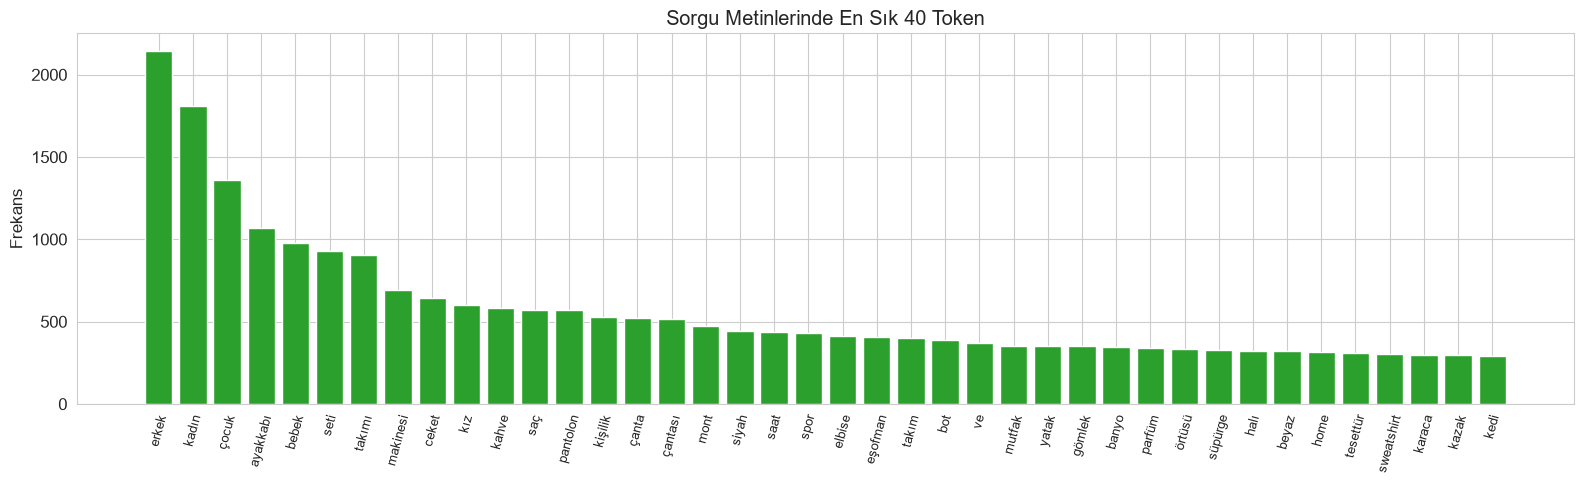


Top 20 token:
  erkek                2,144
  kadın                1,811
  çocuk                1,358
  ayakkabı             1,072
  bebek                  980
  seti                   932
  takımı                 902
  makinesi               691
  ceket                  645
  kız                    601
  kahve                  584
  saç                    572
  pantolon               568
  kişilik                527
  çanta                  522
  çantası                519
  mont                   473
  siyah                  443
  saat                   437
  spor                   432


In [7]:
# En sık geçen kelimeler (stopword yok — kasıtlı, Türkçe e-ticaret sorgularında stopword anlamlı olabilir)
all_query_tokens = [t for tokens in terms['tokens'] for t in tokens]
token_freq = Counter(all_query_tokens)

top_k = 40
top_tokens = token_freq.most_common(top_k)

fig, ax = plt.subplots(figsize=(16, 5))
words, freqs = zip(*top_tokens)
ax.bar(range(top_k), freqs, color=PALETTE[2])
ax.set_xticks(range(top_k))
ax.set_xticklabels(words, rotation=75, fontsize=9)
ax.set_title(f'Sorgu Metinlerinde En Sık {top_k} Token')
ax.set_ylabel('Frekans')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_query_top_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 token:')
for w, f in token_freq.most_common(20):
    print(f'  {w:<20} {f:>5,}')

In [8]:
# Sorgu tipi tahmini: marka içerip içermediği
# items'daki markaları normalize et
brand_set = set(items['brand'].dropna().apply(norm_tr).str.strip())
brand_set.discard('unknown')
brand_set.discard('')

def contains_brand(tokens, brand_set):
    for t in tokens:
        if t in brand_set: return True
    # Birleşik marka isimleri için tam string kontrolü
    full = ' '.join(tokens)
    for b in brand_set:
        if ' ' in b and b in full: return True
    return False

terms['has_brand'] = terms['tokens'].apply(lambda t: contains_brand(t, brand_set))
brand_pct = terms['has_brand'].mean() * 100
print(f'Marka içeren sorgular   : {terms["has_brand"].sum():,} ({brand_pct:.1f}%)')
print(f'Marka içermeyen sorgular: {(~terms["has_brand"]).sum():,} ({100-brand_pct:.1f}%)')

# Tek kelimelik vs çok kelimelik sorgular
print(f"\nTek kelimelik sorgular  : {(terms['token_count']==1).sum():,} ({(terms['token_count']==1).mean()*100:.1f}%)")
print(f"2 kelimelik sorgular    : {(terms['token_count']==2).sum():,} ({(terms['token_count']==2).mean()*100:.1f}%)")
print(f"3+ kelimelik sorgular   : {(terms['token_count']>=3).sum():,} ({(terms['token_count']>=3).mean()*100:.1f}%)")

Marka içeren sorgular   : 31,648 (63.1%)
Marka içermeyen sorgular: 18,505 (36.9%)

Tek kelimelik sorgular  : 5,042 (10.1%)
2 kelimelik sorgular    : 20,891 (41.7%)
3+ kelimelik sorgular   : 24,213 (48.3%)


In [9]:
# 2-gram (bigram) analizi
def get_bigrams(tokens):
    return list(zip(tokens[:-1], tokens[1:]))

all_bigrams = [bg for tokens in terms['tokens'] for bg in get_bigrams(tokens)]
bigram_freq = Counter(all_bigrams)

print('En sık 20 bigram sorgularda:')
for bg, f in bigram_freq.most_common(20):
    print(f"  {' '.join(bg):<30} {f:>5,}")

En sık 20 bigram sorgularda:
  kız çocuk                        376
  spor ayakkabı                    265
  erkek çocuk                      229
  çift kişilik                     220
  tek kişilik                      205
  topuklu ayakkabı                 155
  eşofman altı                     152
  omuz çantası                     129
  nevresim takımı                  127
  kız bebek                        123
  kişilik nevresim                 118
  yatak örtüsü                     115
  kahve makinesi                   114
  lc waikiki                       108
  english home                     108
  yemek takımı                     104
  alt üst                          101
  eşofman takımı                   101
  doğum günü                        98
  güneş gözlüğü                     98


## 4. Ürün Kataloğu (Items) Analizi

=== Ürün Başlığı İstatistikleri ===
       title_len  title_chars
count  962873.00    962873.00
mean        8.60        55.02
std         3.47        22.80
min         0.00         3.00
25%         6.00        37.00
50%         8.00        52.00
75%        11.00        72.00
max        25.00       100.00


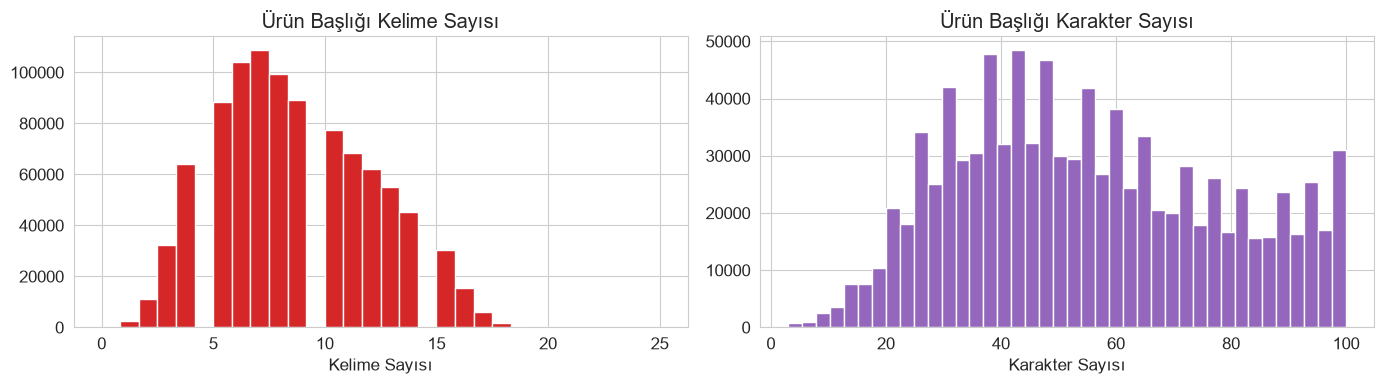

In [10]:
# Başlık analizi
items['title_norm']   = items['title'].apply(norm_tr)
items['title_tokens'] = items['title_norm'].apply(tokenize)
items['title_len']    = items['title_tokens'].apply(len)
items['title_chars']  = items['title_norm'].apply(len)

print('=== Ürün Başlığı İstatistikleri ===')
print(items[['title_len', 'title_chars']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
items['title_len'].clip(upper=30).hist(bins=30, ax=axes[0], color=PALETTE[3], edgecolor='white')
axes[0].set_title('Ürün Başlığı Kelime Sayısı')
axes[0].set_xlabel('Kelime Sayısı')

items['title_chars'].clip(upper=200).hist(bins=40, ax=axes[1], color=PALETTE[4], edgecolor='white')
axes[1].set_title('Ürün Başlığı Karakter Sayısı')
axes[1].set_xlabel('Karakter Sayısı')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_title_length.png', dpi=150, bbox_inches='tight')
plt.show()

=== Kategori Derinliği Dağılımı ===
  Derinlik 2:   30,915 ürün (3.2%)
  Derinlik 3:  362,553 ürün (37.7%)
  Derinlik 4:  357,069 ürün (37.1%)
  Derinlik 5:  191,413 ürün (19.9%)
  Derinlik 6:   20,923 ürün (2.2%)


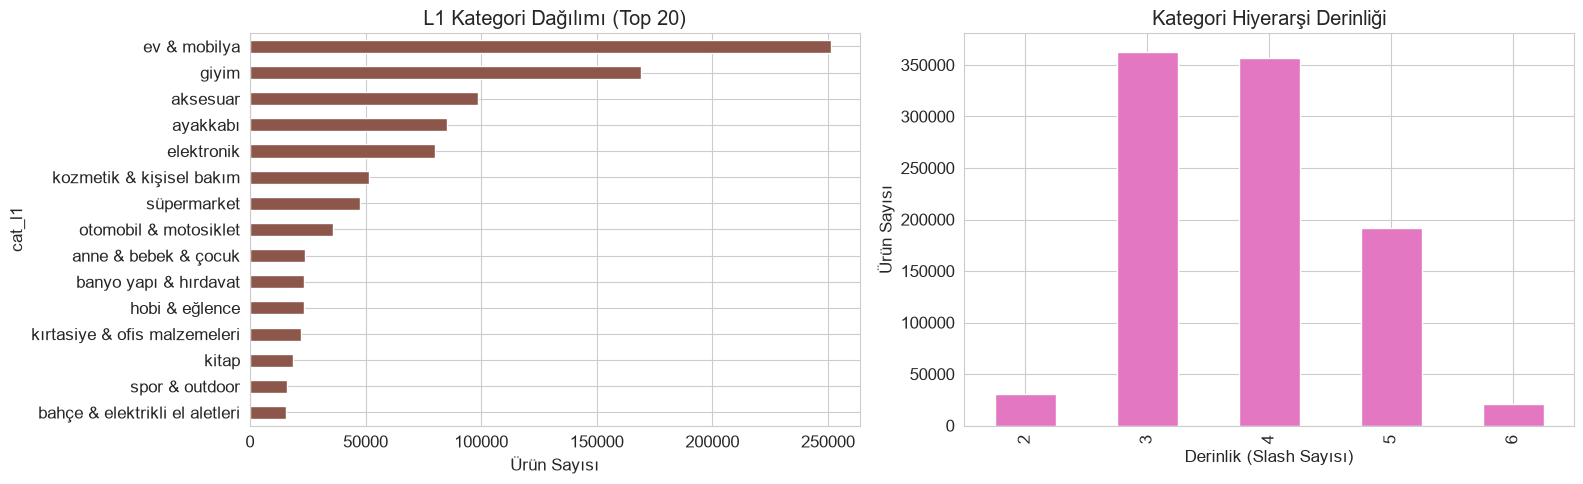


Benzersiz L1 kategori sayısı : 15
Benzersiz L2 kategori sayısı : 118
Benzersiz L3 kategori sayısı : 1043
Benzersiz yaprak kategori    : 2932


In [11]:
# Kategori hiyerarşisi analizi
items['cat_parts']   = items['category'].fillna('').apply(lambda x: [c.strip() for c in x.split('/') if c.strip()])
items['cat_depth']   = items['cat_parts'].apply(len)
items['cat_l1']      = items['cat_parts'].apply(lambda x: x[0] if x else 'bilinmiyor')
items['cat_l2']      = items['cat_parts'].apply(lambda x: x[1] if len(x) > 1 else '')
items['cat_l3']      = items['cat_parts'].apply(lambda x: x[2] if len(x) > 2 else '')
items['cat_leaf']    = items['cat_parts'].apply(lambda x: x[-1] if x else '')

print('=== Kategori Derinliği Dağılımı ===')
depth_vc = items['cat_depth'].value_counts().sort_index()
for d, c in depth_vc.items():
    print(f'  Derinlik {d}: {c:>8,} ürün ({c/len(items)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# L1 kategori dağılımı
l1_vc = items['cat_l1'].value_counts()
l1_vc.head(20).plot(kind='barh', ax=axes[0], color=PALETTE[5])
axes[0].set_title('L1 Kategori Dağılımı (Top 20)')
axes[0].set_xlabel('Ürün Sayısı')
axes[0].invert_yaxis()

# Kategori derinliği
depth_vc.plot(kind='bar', ax=axes[1], color=PALETTE[6])
axes[1].set_title('Kategori Hiyerarşi Derinliği')
axes[1].set_xlabel('Derinlik (Slash Sayısı)')
axes[1].set_ylabel('Ürün Sayısı')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_category_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBenzersiz L1 kategori sayısı : {items["cat_l1"].nunique()}')
print(f'Benzersiz L2 kategori sayısı : {items["cat_l2"].nunique()}')
print(f'Benzersiz L3 kategori sayısı : {items["cat_l3"].nunique()}')
print(f'Benzersiz yaprak kategori    : {items["cat_leaf"].nunique()}')

Toplam benzersiz marka sayısı: 79,790
'unknown' marka sayısı       : 1

Kaç markada kaç ürün var?
 urun_sayisi  marka_sayisi
           1         30161
           2         12291
           3          7080
           4          4646
           5          3500
           6          2578
           7          2080
           8          1699
           9          1356
          10          1148


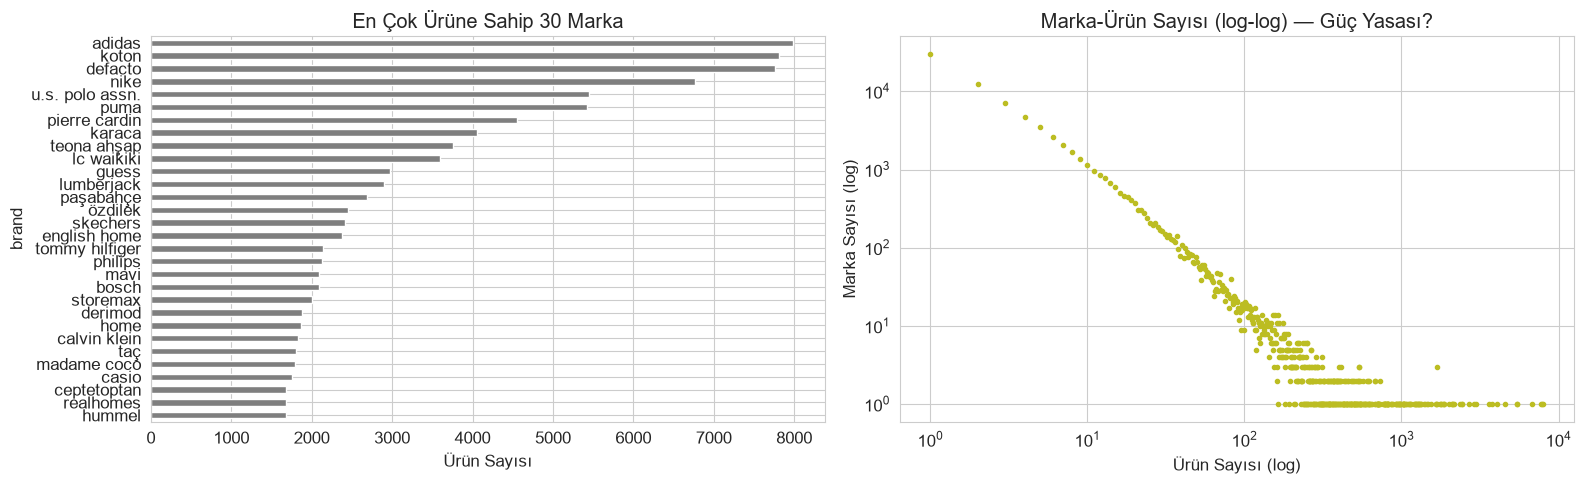

In [15]:
# Marka analizi
brand_vc = items['brand'].fillna('bilinmiyor').value_counts()
print(f'Toplam benzersiz marka sayısı: {items["brand"].nunique():,}')
print(f"'unknown' marka sayısı       : {(items['brand'] == 'unknown').sum():,}")

# Ürün sayısına göre marka dağılımı
brand_cnt_dist = (
    brand_vc
    .value_counts()
    .rename_axis('urun_sayisi')
    .reset_index(name='marka_sayisi')
)
brand_cnt_dist.columns = ['urun_sayisi', 'marka_sayisi']
print('\nKaç markada kaç ürün var?')
print(brand_cnt_dist.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
brand_vc.head(30).plot(kind='barh', ax=axes[0], color=PALETTE[7])
axes[0].set_title('En Çok Ürüne Sahip 30 Marka')
axes[0].set_xlabel('Ürün Sayısı')
axes[0].invert_yaxis()

# Güç yasası dağılımı
brand_vc_log = brand_vc.value_counts().sort_index()
axes[1].loglog(brand_vc_log.index, brand_vc_log.values, 'o', markersize=3, color=PALETTE[8])
axes[1].set_title('Marka-Ürün Sayısı (log-log) — Güç Yasası?')
axes[1].set_xlabel('Ürün Sayısı (log)')
axes[1].set_ylabel('Marka Sayısı (log)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig05_brand_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Attributes analizi
print('=== Attributes Alan Analizi ===')
items['attr_missing'] = items['attributes'].isnull() | (items['attributes'].fillna('').str.strip() == '')
print(f"Attributes boş/null olan ürün : {items['attr_missing'].sum():,} ({items['attr_missing'].mean()*100:.1f}%)")

# Parse et ve anahtar frekanslarını bul (örneklem üzerinde)
sample_size = min(50000, len(items))
sample_items = items.sample(sample_size, random_state=42)

attr_key_counter = Counter()
attr_value_counter = defaultdict(Counter)

for attr_str in sample_items['attributes'].dropna():
    parsed = parse_attributes(attr_str)
    for k, v in parsed.items():
        attr_key_counter[k] += 1
        attr_value_counter[k][v] += 1

print(f'\nBenzersiz attribute anahtarı ({sample_size} örneklemde): {len(attr_key_counter)}')
print('\nEn sık 30 attribute anahtarı:')
for k, cnt in attr_key_counter.most_common(30):
    top_vals = ', '.join([f'"{v}"' for v, _ in attr_value_counter[k].most_common(3)])
    print(f'  {k:<35} {cnt:>6,}  → top değerler: {top_vals}')

=== Attributes Alan Analizi ===
Attributes boş/null olan ürün : 0 (0.0%)

Benzersiz attribute anahtarı (50000 örneklemde): 952

En sık 30 attribute anahtarı:
  renk                                38,787  → top değerler: "siyah", "beyaz", "çok renkli"
  color detail                        38,119  → top değerler: "siyah", "beyaz", "gri"
  menşei                              36,138  → top değerler: "tr", "cn", "vn"
  materyal                            29,264  → top değerler: "pamuklu", "polyester", "tekstil"
  yıkama talimatı                     18,312  → top değerler: "type 1", "type 4", "type 2"
  desen                               16,950  → top değerler: "düz", "baskılı", "desenli"
  ortam                               13,521  → top değerler: "casual/günlük", "günlük", "sportswear"
  kumaş tipi                          12,653  → top değerler: "dokuma", "belirtilmemiş", "örme"
  sürdürülebilirlik detayı            12,146  → top değerler: "hayır", "evet", "organik"
  materyal bileşeni 

In [17]:
# En önemli attribute: renk
print('"renk" attribute değer dağılımı (Top 30):')
for v, c in attr_value_counter.get('renk', Counter()).most_common(30):
    print(f'  {v:<30} {c:>5,}')

# materyal
print('\n"materyal" attribute değer dağılımı (Top 20):')
for v, c in attr_value_counter.get('materyal', Counter()).most_common(20):
    print(f'  {v:<30} {c:>5,}')

"renk" attribute değer dağılımı (Top 30):
  siyah                          6,709
  beyaz                          5,662
  çok renkli                     5,149
  gri                            2,897
  kahverengi                     2,564
  bej                            2,376
  pembe                          1,717
  mavi                           1,521
  lacivert                       1,290
  yeşil                          1,212
  kırmızı                        1,037
  altın                          1,029
  sarı                             953
  gümüş                            795
  turuncu                          731
  ekru                             617
  mor                              596
  bordo                            473
  haki                             401
  metalik                          375
  krem                             228
  turkuaz                          127
  şeffaf                           124
  karışık                           30
  krom                


Ürün başına attribute sayısı istatistikleri:
count    962873.00
mean         10.56
std           7.47
min           0.00
25%           5.00
50%           8.00
75%          16.00
max          34.00
Name: attr_count, dtype: float64


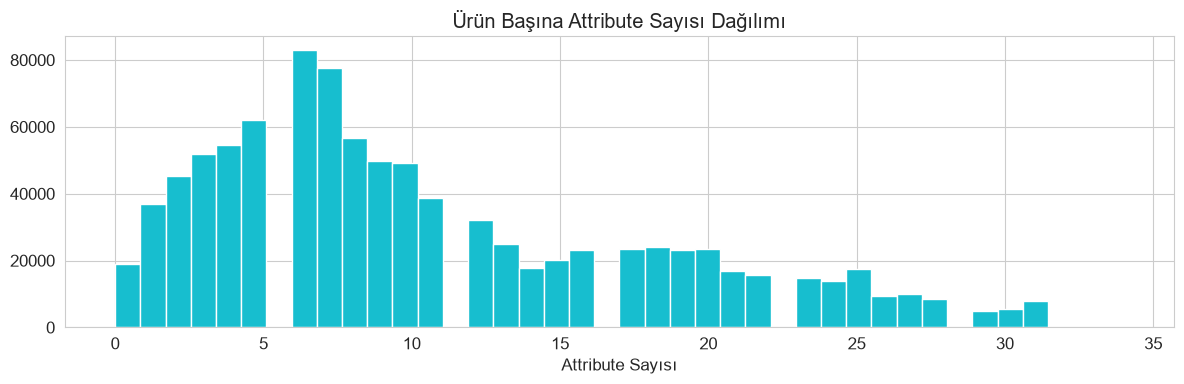

In [18]:
# Attribute sayısı per ürün dağılımı
items['attr_count'] = items['attributes'].apply(
    lambda x: len(parse_attributes(x)) if isinstance(x, str) else 0)

print('\nÜrün başına attribute sayısı istatistikleri:')
print(items['attr_count'].describe().round(2))

fig, ax = plt.subplots(figsize=(12, 4))
items['attr_count'].clip(upper=40).hist(bins=40, ax=ax, color=PALETTE[9], edgecolor='white')
ax.set_title('Ürün Başına Attribute Sayısı Dağılımı')
ax.set_xlabel('Attribute Sayısı')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig06_attr_count.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Eğitim Çiftleri (Training Pairs) Analizi

In [19]:
# Tüm label'ler 1 mi?
print(f'Training pairs label dağılımı:\n{train["label"].value_counts()}')
print()

# Kaç benzersiz term ve item var?
train_terms_unique = train['term_id'].nunique()
train_items_unique = train['item_id'].nunique()

print(f'Eğitim setinde benzersiz term sayısı : {train_terms_unique:,}')
print(f'Eğitim setinde benzersiz item sayısı : {train_items_unique:,}')
print(f'Tüm termlerin kaçı eğitimde?         : {train_terms_unique/len(terms)*100:.1f}% ({train_terms_unique}/{len(terms)})')
print(f'Tüm ürünlerin kaçı eğitimde?         : {train_items_unique/len(items)*100:.1f}% ({train_items_unique}/{len(items)})')

Training pairs label dağılımı:
label
1    250000
Name: count, dtype: int64

Eğitim setinde benzersiz term sayısı : 17,968
Eğitim setinde benzersiz item sayısı : 229,416
Tüm termlerin kaçı eğitimde?         : 35.8% (17968/50153)
Tüm ürünlerin kaçı eğitimde?         : 23.8% (229416/962873)


=== Bir Term İçin Kaç Pozitif Ürün Var? ===
count    17968.00
mean        13.91
std         33.10
min          1.00
25%          3.00
50%          7.00
75%         15.00
max       1525.00
Name: item_id, dtype: float64

=== Bir Ürün Kaç Farklı Term ile Eşleşiyor? ===
count    229416.00
mean          1.09
std           0.33
min           1.00
25%           1.00
50%           1.00
75%           1.00
max           7.00
Name: term_id, dtype: float64


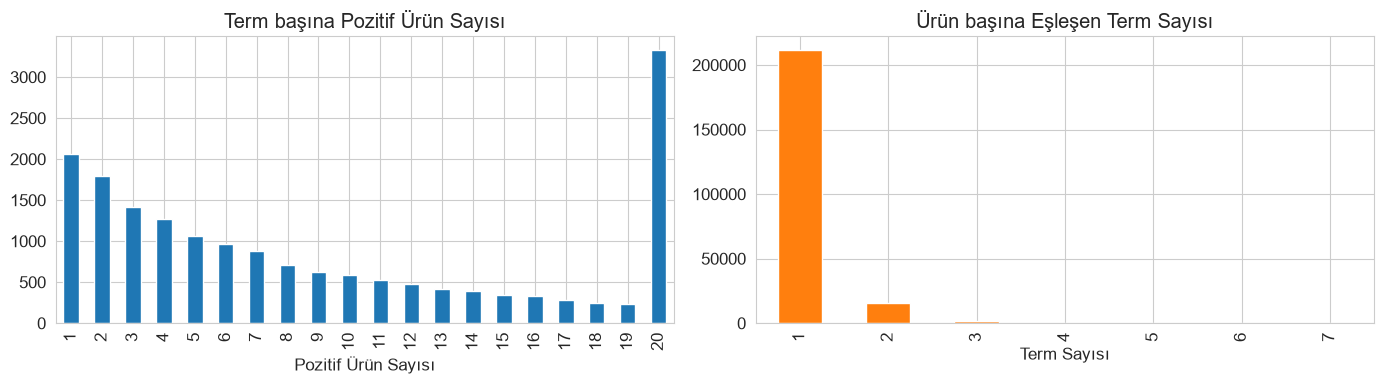

In [20]:
# Her term için kaç pozitif ürün var?
items_per_term = train.groupby('term_id')['item_id'].count()
print('=== Bir Term İçin Kaç Pozitif Ürün Var? ===')
print(items_per_term.describe().round(2))

# Her item için kaç farklı term'le eşleşiyor?
terms_per_item = train.groupby('item_id')['term_id'].count()
print('\n=== Bir Ürün Kaç Farklı Term ile Eşleşiyor? ===')
print(terms_per_item.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
items_per_term.clip(upper=20).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=PALETTE[0])
axes[0].set_title('Term başına Pozitif Ürün Sayısı')
axes[0].set_xlabel('Pozitif Ürün Sayısı')

terms_per_item.clip(upper=20).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=PALETTE[1])
axes[1].set_title('Ürün başına Eşleşen Term Sayısı')
axes[1].set_xlabel('Term Sayısı')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig07_pairing_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Birleştirilmiş eğitim seti: (250000, 17)

=== Sorgu-Başlık Token Örtüşme Oranı (eğitim pozitif çiftleri) ===
count    20000.000
mean         0.546
std          0.374
min          0.000
25%          0.333
50%          0.500
75%          1.000
max          1.000
Name: overlap_ratio, dtype: float64


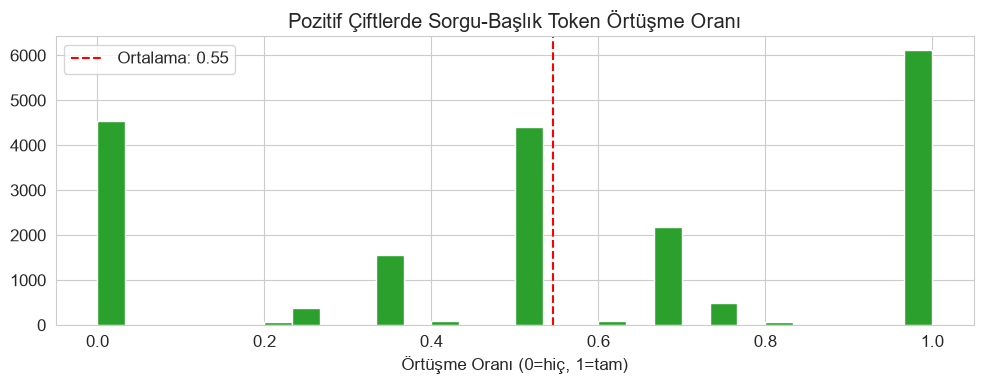

In [21]:
# Eğitim çiftlerini tam tablo ile birleştir
train_full = (train
    .merge(terms[['term_id', 'query', 'tokens', 'token_count']], on='term_id', how='left')
    .merge(items[['item_id', 'title', 'title_tokens', 'title_len', 'cat_l1', 'cat_l2', 'cat_leaf', 'brand', 'gender', 'age_group', 'attr_count']], on='item_id', how='left')
)

print(f'Birleştirilmiş eğitim seti: {train_full.shape}')
print()

# Sorgu kelimelerinin title'da geçme oranı
def overlap_ratio(row):
    q_tokens = set(row['tokens']) if isinstance(row['tokens'], list) else set()
    t_tokens = set(row['title_tokens']) if isinstance(row['title_tokens'], list) else set()
    if not q_tokens: return 0.0
    return len(q_tokens & t_tokens) / len(q_tokens)

# Hesaplama yoğun — örneklem üzerinde
sample_train = train_full.sample(min(20000, len(train_full)), random_state=42)
sample_train['overlap_ratio'] = sample_train.apply(overlap_ratio, axis=1)

print('=== Sorgu-Başlık Token Örtüşme Oranı (eğitim pozitif çiftleri) ===')
print(sample_train['overlap_ratio'].describe().round(3))

fig, ax = plt.subplots(figsize=(10, 4))
sample_train['overlap_ratio'].hist(bins=30, ax=ax, color=PALETTE[2], edgecolor='white')
ax.set_title('Pozitif Çiftlerde Sorgu-Başlık Token Örtüşme Oranı')
ax.set_xlabel('Örtüşme Oranı (0=hiç, 1=tam)')
ax.axvline(sample_train['overlap_ratio'].mean(), color='red', linestyle='--', label=f'Ortalama: {sample_train["overlap_ratio"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig08_overlap_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Sıfır örtüşmeli pozitif çiftler — zor vakalar!
zero_overlap = sample_train[sample_train['overlap_ratio'] == 0]
print(f'Sıfır kelime örtüşmeli pozitif çift (örneklemde): {len(zero_overlap):,} ({len(zero_overlap)/len(sample_train)*100:.1f}%)')
print('Bunlar neden alakalı?  — Marka sorgusu, eş anlamlı kelimeler, kategorik eşleşme vb.')
print()
print('Örnek sıfır örtüşmeli pozitif çiftler:')
for _, row in zero_overlap.sample(min(8, len(zero_overlap)), random_state=1).iterrows():
    print(f'  Sorgu: "{row["query"]}"  →  Ürün: "{str(row["title"])[:70]}"')

Sıfır kelime örtüşmeli pozitif çift (örneklemde): 4,532 (22.7%)
Bunlar neden alakalı?  — Marka sorgusu, eş anlamlı kelimeler, kategorik eşleşme vb.

Örnek sıfır örtüşmeli pozitif çiftler:
  Sorgu: "erkek beyaz spor ayakkabı"  →  Ürün: "run star hıke canvas platform"
  Sorgu: "kemal tanca çanta"  →  Ürün: "hakiki deri kadın omuz çantası 2755"
  Sorgu: "paradontax"  →  Ürün: "nane ferahlığı alkolsüz ağız bakım suyu 500ml"
  Sorgu: "pişirme"  →  Ürün: "maya 7 parça granit desenli tencere seti altın kulp beyaz"
  Sorgu: "merrell"  →  Ürün: "hydro runner kadın outdoor ayakkabı - bej"
  Sorgu: "madame coco bardak"  →  Ürün: "flamingo su bardağı seti 290 ml 3lü"
  Sorgu: "lotto"  →  Ürün: "madison wmn 4fx"
  Sorgu: "terazi"  →  Ürün: "taşınabilir el bagaj valiz bavul tartısı askılı işıklı 50 kg kapasitel"


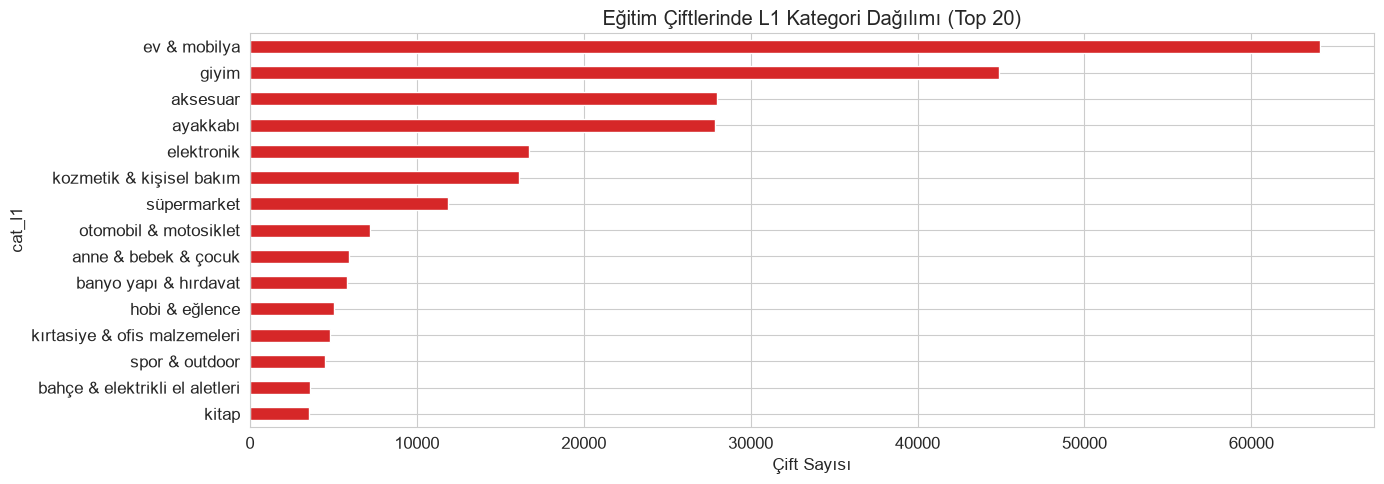

In [24]:
# Eğitim çiftlerinin L1 kategori dağılımı
if 'cat_l1' not in train_full.columns:
    train_full = train_full.merge(items[['item_id', 'cat_l1']], on='item_id', how='left')

cat_dist = train_full['cat_l1'].value_counts()
# (cat_l1 zaten train_full'da var, direkt kullanalım)
cat_dist = train_full['cat_l1'].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
cat_dist.head(20).plot(kind='barh', ax=ax, color=PALETTE[3])
ax.set_title('Eğitim Çiftlerinde L1 Kategori Dağılımı (Top 20)')
ax.set_xlabel('Çift Sayısı')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig09_train_cat_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Test Seti Analizi

In [26]:
test_terms_unique = test['term_id'].nunique()
test_items_unique = test['item_id'].nunique()

# Train'de de var mı?
train_term_set = set(train['term_id'].unique())
train_item_set = set(train['item_id'].unique())

test_term_in_train  = test['term_id'].isin(train_term_set).sum()
test_item_in_train  = test['item_id'].isin(train_item_set).sum()

print('=== Test Seti Kapsam Analizi ===')
print(f'Benzersiz test termi     : {test_terms_unique:,}')
print(f"  → Train'de de geçen   : {test_term_in_train:,} satır ({test_term_in_train/len(test)*100:.1f}%)")

test_unique_terms = set(test['term_id'].unique())
overlap_terms = test_unique_terms & train_term_set
only_test_terms = test_unique_terms - train_term_set

print(f'\nUnique test termlerinin {len(overlap_terms)/len(test_unique_terms)*100:.1f}%\'i eğitimde de görünüyor')
print(f'Yalnızca test setinde olan term sayısı: {len(only_test_terms):,}')
print()

test_unique_items = set(test['item_id'].unique())
overlap_items = test_unique_items & train_item_set
only_test_items = test_unique_items - train_item_set

print(f'Benzersiz test ürünü     : {test_items_unique:,}')
print(f'Unique test ürünlerinin {len(overlap_items)/len(test_unique_items)*100:.1f}%\'i eğitimde de görünüyor')
print(f'Yalnızca test setinde olan ürün sayısı: {len(only_test_items):,}')

=== Test Seti Kapsam Analizi ===
Benzersiz test termi     : 32,185
  → Train'de de geçen   : 0 satır (0.0%)

Unique test termlerinin 0.0%'i eğitimde de görünüyor
Yalnızca test setinde olan term sayısı: 32,185

Benzersiz test ürünü     : 929,781
Unique test ürünlerinin 21.1%'i eğitimde de görünüyor
Yalnızca test setinde olan ürün sayısı: 733,457


In [27]:
# Test setindeki term başına ürün sayısı dağılımı
test_items_per_term = test.groupby('term_id')['item_id'].count()
print('=== Test Seti: Term Başına Ürün Sayısı ===')
print(test_items_per_term.describe().round(2))

# Tahmin: pozitif oran test setinde kaç olabilir?
# Eğitimde ortalama N pozitif var, test setindeki toplam çift sayısına oranla...
avg_pos_per_term = items_per_term.mean()
avg_test_per_term = test_items_per_term.mean()
estimated_pos_rate = avg_pos_per_term / avg_test_per_term
print(f'\nEğitimde ortalama pozitif per term: {avg_pos_per_term:.1f}')
print(f'Test setinde ortalama item per term: {avg_test_per_term:.1f}')
print(f'→ Tahmini pozitif oran (rough): {estimated_pos_rate:.1%}')
print(f'→ Tahmini negatif oran (rough): {1-estimated_pos_rate:.1%}')

=== Test Seti: Term Başına Ürün Sayısı ===
count    32185.00
mean       104.39
std         45.50
min        100.00
25%        100.00
50%        100.00
75%        100.00
max       3680.00
Name: item_id, dtype: float64

Eğitimde ortalama pozitif per term: 13.9
Test setinde ortalama item per term: 104.4
→ Tahmini pozitif oran (rough): 13.3%
→ Tahmini negatif oran (rough): 86.7%


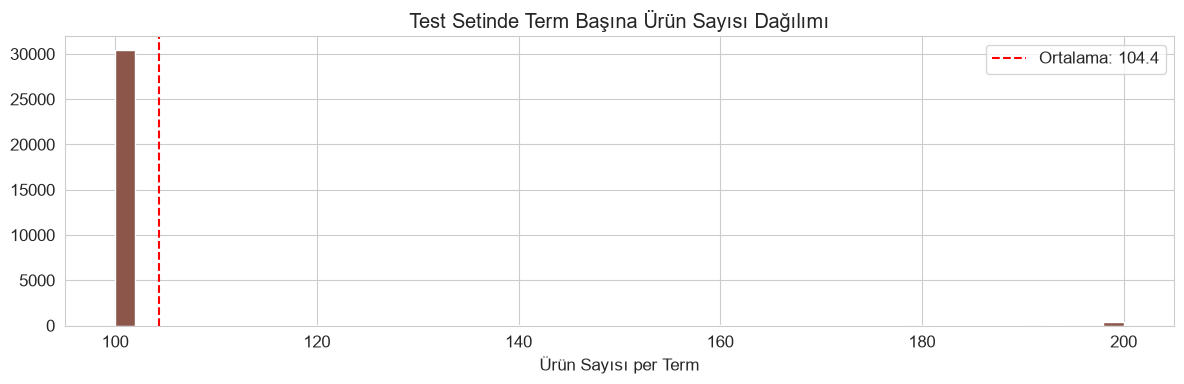

In [28]:
# Test setindeki term başına item sayısı histogramı
fig, ax = plt.subplots(figsize=(12, 4))
test_items_per_term.clip(upper=200).hist(bins=50, ax=ax, color=PALETTE[5], edgecolor='white')
ax.set_title('Test Setinde Term Başına Ürün Sayısı Dağılımı')
ax.set_xlabel('Ürün Sayısı per Term')
ax.axvline(test_items_per_term.mean(), color='red', linestyle='--', label=f'Ortalama: {test_items_per_term.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig10_test_items_per_term.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Metin Benzerliği — Temel Sinyal Analizi

In [29]:
# Ürün için tam metin (baseline gibi: title + category + brand + gender + age_group + attributes)
items['full_text'] = (
    items['title'].fillna('') + ' ' +
    items['category'].fillna('') + ' ' +
    items['brand'].fillna('') + ' ' +
    items['gender'].fillna('') + ' ' +
    items['age_group'].fillna('') + ' ' +
    items['attributes'].fillna('')
)
items['full_tokens'] = items['full_text'].apply(lambda x: set(tokenize(norm_tr(x))))

print('Ürün tam metni örnek:')
for _, row in items.sample(3, random_state=7).iterrows():
    print(f'  [{row["item_id"]}] {str(row["full_text"])[:100]}...')
    print()

Ürün tam metni örnek:
  [ITEM_c478aa59549f] taşlı yuvarlak ikili küpe aksesuar/takı & mücevher/küpe/altın küpe bygoldenhouse kadın yetişkin ayar...

  [ITEM_04173f7da34d] cup cake no.4 beyaz 600 adet (5x3)cm ev & mobilya/ev/sofra & mutfak/pişirme/fırın ve kek kalıbı past...

  [ITEM_fb2d0ccdfe65] mikro çok amaçlı dolap ev & mobilya/mobilya/mutfak & banyo mobilyası/mutfak mobilyası/mutfak dolapla...



In [30]:
# Sorgu token'larının tam metinde geçme oranı — örneklem
sample_train2 = train.sample(min(10000, len(train)), random_state=99)

term_tok_map  = dict(zip(terms['term_id'], terms['tokens']))
item_ftok_map = dict(zip(items['item_id'], items['full_tokens']))

def full_overlap_ratio(term_id, item_id):
    q_toks = set(term_tok_map.get(term_id, []))
    i_toks = item_ftok_map.get(item_id, set())
    if not q_toks: return 0.0
    return len(q_toks & i_toks) / len(q_toks)

sample_train2['full_overlap'] = sample_train2.apply(
    lambda r: full_overlap_ratio(r['term_id'], r['item_id']), axis=1)

print('=== Sorgu-Tam Metin Örtüşme Oranı (Pozitif Çiftler) ===')
print(sample_train2['full_overlap'].describe().round(3))

zero_full = (sample_train2['full_overlap'] == 0).mean()
print(f'\nSıfır tam metin örtüşmeli pozitif çift oranı: {zero_full:.1%}')
print('→ Bu oran model için en zor vakalar (muhtemelen eş anlamlılar, yazım varyasyonları, marka sorguları)')

=== Sorgu-Tam Metin Örtüşme Oranı (Pozitif Çiftler) ===
count    10000.000
mean         0.889
std          0.232
min          0.000
25%          1.000
50%          1.000
75%          1.000
max          1.000
Name: full_overlap, dtype: float64

Sıfır tam metin örtüşmeli pozitif çift oranı: 2.9%
→ Bu oran model için en zor vakalar (muhtemelen eş anlamlılar, yazım varyasyonları, marka sorguları)


In [31]:
# Baseline performans tahmini
# Eğitimde pozitif çiftlerin tam metin overlap >= 1 ise 1 diyoruz
from sklearn.metrics import f1_score

# Bu sadece pozitif çiftleri test ederek recall-like bir ölçüm
# (gerçek F1 için negatifler de lazım, burada sadece pozitif tarafı görebiliyoruz)
baseline_pred = (sample_train2['full_overlap'] >= 1/sample_train2.apply(
    lambda r: max(len(term_tok_map.get(r['term_id'], [1])), 1), axis=1)).astype(int)

word_overlap_recall = (sample_train2['full_overlap'] > 0).mean()
print(f'Pozitif çiftlerde kelime örtüşme recall: {word_overlap_recall:.1%}')
print(f'→ Baseline {word_overlap_recall:.0%} pozitifi doğru sınıflandırabilir')
print(f'→ %{100-word_overlap_recall*100:.0f} pozitif kötü sınıflandırılır — embedding/semantic modeli gerektirir')

Pozitif çiftlerde kelime örtüşme recall: 97.1%
→ Baseline 97% pozitifi doğru sınıflandırabilir
→ %3 pozitif kötü sınıflandırılır — embedding/semantic modeli gerektirir


## 8. Negatif Örnekleme Stratejileri — Derinlemesine Analiz

=== Test Seti: Term Başına L1 Kategori Çeşitliliği ===
count    32185.00
mean        12.05
std          3.00
min          1.00
25%         12.00
50%         13.00
75%         14.00
max         15.00
Name: cat_l1, dtype: float64


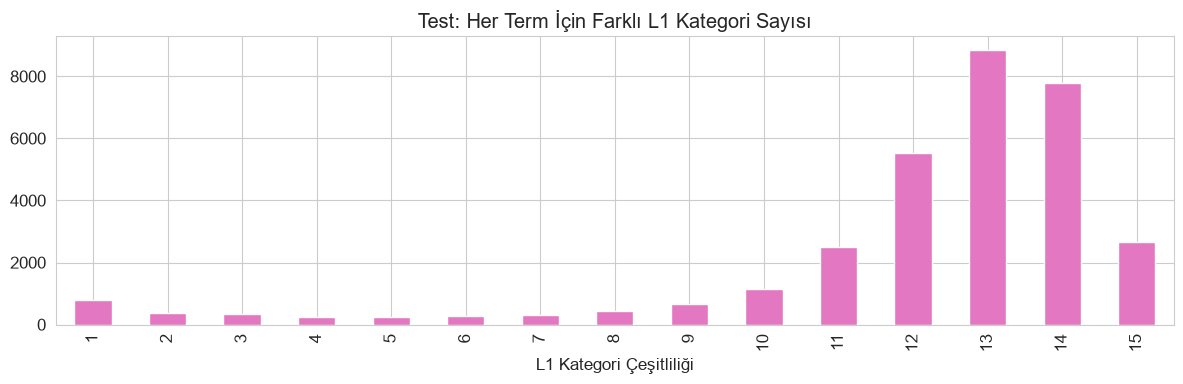


Ortalam 12.0 farklı L1 kategoriden ürün → negatifler kategorik çeşitlilik içeriyor


In [32]:
'''
Negatif örnekleme stratejileri ve analitik değerlendirmeleri:

1. RASTGELE NEGATİF (Random Negatives)
   - Rastgele (term, item) çiftleri oluştur
   - Kolay: yüksek precision, düşük recall gerektiren bir model çıkabilir
   - Dezavantaj: Çok kolay negatifleri model öğrenir, test'teki zor negatiflerde başarısız olur
   
2. AYNI KATEGORİDEN NEGATİF (In-Category Hard Negatives)
   - Bir sorgu için aynı L1/L2 kategorideki farklı ürünlerden örnekle
   - "erkek bot" sorgusuna "erkek sandalet" negatifi ver
   - Daha zor → model daha iyi ayrım öğrenir
   
3. BM25 TABANLI HARD NEGATIVES
   - BM25 ile yüksek skor alan ama aslında alakasız olanlar
   - Test seti büyük ihtimalle BM25 ile oluşturulmuş — en gerçekçi strateji bu
   
4. IN-BATCH NEGATIVES (Contrastive Learning)
   - Batch içindeki diğer pozitif çiftlerin item'larını negatif olarak kullan
   - Embedding tabanlı modeller için ideal
'''

# Test setinin nasıl oluşturulduğunu anlamak için basit analiz
# Her term için test setindeki item'lar ne kadar kategorik çeşitli?

test_full = test.merge(items[['item_id','cat_l1','cat_l2']], on='item_id', how='left')

# Bir term için test setindeki L1 kategori sayısı
cat_diversity_per_term = test_full.groupby('term_id')['cat_l1'].nunique()

print('=== Test Seti: Term Başına L1 Kategori Çeşitliliği ===')
print(cat_diversity_per_term.describe().round(2))

fig, ax = plt.subplots(figsize=(12, 4))
cat_diversity_per_term.clip(upper=30).value_counts().sort_index().plot(
    kind='bar', ax=ax, color=PALETTE[6])
ax.set_title('Test: Her Term İçin Farklı L1 Kategori Sayısı')
ax.set_xlabel('L1 Kategori Çeşitliliği')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig11_test_cat_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOrtalam {cat_diversity_per_term.mean():.1f} farklı L1 kategoriden ürün → negatifler kategorik çeşitlilik içeriyor')

In [33]:
# Basit negatif örnekleme kalitesi testi
# Rastgele negatif çiftin örtüşme oranı dağılımı
np.random.seed(42)
n_neg_sample = 5000

random_term_ids = train['term_id'].sample(n_neg_sample, replace=True).values
random_item_ids = items['item_id'].sample(n_neg_sample).values

# Bunları gerçek pozitif çift olup olmadığını kontrol et
pos_set = set(zip(train['term_id'], train['item_id']))
is_accidental_positive = sum(1 for t, i in zip(random_term_ids, random_item_ids) if (t, i) in pos_set)
print(f'Rastgele seçilen {n_neg_sample} çiftten yanlışlıkla pozitif olan: {is_accidental_positive} ({is_accidental_positive/n_neg_sample:.2%})')
print('→ Rastgele negatif oluşturmak güvenli (yanlış pozitif oranı düşük)')
print()

# Rastgele negatif çiftlerde kelime örtüşmesi ne kadar?
rand_neg_overlaps = []
for t_id, i_id in zip(random_term_ids[:2000], random_item_ids[:2000]):
    rand_neg_overlaps.append(full_overlap_ratio(t_id, i_id))

rand_neg_overlaps = np.array(rand_neg_overlaps)
print(f'Rastgele negatif çiftlerde ortalama örtüşme: {rand_neg_overlaps.mean():.3f}')
print(f'Rastgele negatif çiftlerde sıfır örtüşme oranı: {(rand_neg_overlaps==0).mean():.1%}')
print('→ Çoğu rastgele negatif zaten sıfır örtüşme sahip — çok kolay negatifleri temsil ediyor')

Rastgele seçilen 5000 çiftten yanlışlıkla pozitif olan: 1 (0.02%)
→ Rastgele negatif oluşturmak güvenli (yanlış pozitif oranı düşük)

Rastgele negatif çiftlerde ortalama örtüşme: 0.026
Rastgele negatif çiftlerde sıfır örtüşme oranı: 93.4%
→ Çoğu rastgele negatif zaten sıfır örtüşme sahip — çok kolay negatifleri temsil ediyor


## 9. Özellik Mühendisliği Potansiyeli

In [34]:
'''
Özellik mühendisliği önerileri — her birinin analitik gerekçesiyle:
'''

# A) TOKEN ÖRTÜŞME ÖZELLİKLERİ
# ──────────────────────────────
# query_title_overlap_count     : Sorgu token'larının kaçı başlıkta geçiyor?
# query_title_overlap_ratio     : Oran (Jaccard)
# query_full_overlap_count      : Tam metindeki örtüşme
# query_full_overlap_ratio      : Tam metinde oran
# any_overlap_binary            : Baseline binary özelliği

# B) BAŞLIK SEMANTİK ÖZELLİKLERİ
# ──────────────────────────────
# title_starts_with_query       : Ürün başlığı doğrudan sorgu ile mi başlıyor?
# query_is_substring_of_title   : Sorgu başlıkta tam alt dize mi?
# title_token_len               : Başlık uzunluğu (kısa başlıklar genellikle genel sorgu için)

# C) METAVERİ EŞLEŞMESİ ÖZELLİKLERİ
# ──────────────────────────────
# query_contains_brand          : Sorgu marka içeriyor mu?
# brand_in_query                : Ürünün markası sorgu metninde geçiyor mu?
# query_gender_match            : Sorgudaki cinsiyet ifadesi ürün gender ile eşleşiyor mu?
# query_age_match               : Sorgudaki yaş ifadesi ürün age_group ile eşleşiyor mu?
# category_token_overlap        : Kategori metni sorgu ile ne kadar örtüşüyor?

# D) NÜMERİK ÖZELLİKLER
# ──────────────────────────────
# query_len_tokens              : Sorgu token sayısı
# item_attr_count               : Ürün attribute sayısı (zenginlik göstergesi)
# item_cat_depth                : Kategori derinliği
# bm25_score                    : BM25 benzerlik skoru (en önemli sinyal)
# cosine_sim_tfidf              : TF-IDF tabanlı cosine benzerliği

# E) RENK / MATERYAL EŞLEŞMESİ
# ──────────────────────────────
# color_mentioned_in_query      : Sorguda renk var mı?
# color_match                   : Ürünün rengi sorgu ile eşleşiyor mu?
# material_mentioned_in_query   : Sorguda materyal var mı?
# material_match                : Ürünün materyali sorgu ile eşleşiyor mu?

print('Öneri edilen özellik grupları yukarıdaki hücredir — kod olarak görmek için bir sonraki hücreye bakınız.')

# Örnek özellik fonksiyonları
COLORS_TR = {'kırmızı','mavi','yeşil','sarı','siyah','beyaz','gri','mor','turuncu','pembe',
             'kahverengi','bej','lacivert','bordo','krem','altın','gümüş','bronz','şampanya'}
GENDER_TR  = {'erkek','kadın','kız','bay','bayan','unisex','çocuk','bebek'}
AGE_TR     = {'bebek','çocuk','yetişkin','genç','senior'}

def extract_features(query_tokens, title_tokens, full_tokens, brand, gender, age_group, category):
    q = set(query_tokens)
    if not q:
        return {k: 0 for k in ['title_overlap_ratio','full_overlap_ratio','brand_in_q',
                                 'gender_match','color_in_q','color_match','cat_overlap']}
    t  = set(title_tokens) if isinstance(title_tokens, list) else set()
    f  = full_tokens if isinstance(full_tokens, set) else set()
    cat_tok = set(tokenize(norm_tr(category or '')))
    b_tok   = set(tokenize(norm_tr(brand or '')))
    
    color_in_q  = bool(q & COLORS_TR)
    item_color  = COLORS_TR & f
    color_match = bool(color_in_q and (q & item_color))
    
    q_gender    = q & GENDER_TR
    item_gender = set(tokenize(norm_tr(gender or '')))
    gender_match = bool(q_gender & item_gender) if q_gender else True  # belirtilmemişse ceza verme
    
    return {
        'title_overlap_ratio': len(q & t) / len(q),
        'full_overlap_ratio' : len(q & f) / len(q),
        'title_jaccard'      : len(q & t) / max(len(q | t), 1),
        'brand_in_q'         : int(bool(b_tok & q)),
        'gender_match'       : int(gender_match),
        'color_in_q'         : int(color_in_q),
        'color_match'        : int(color_match),
        'cat_overlap'        : len(q & cat_tok) / len(q),
    }

# Test et
ex_row = train_full.iloc[0]
ex_feats = extract_features(
    ex_row['tokens'], ex_row['title_tokens'], 
    item_ftok_map.get(ex_row['item_id'], set()),
    ex_row.get('brand',''), ex_row.get('gender',''), ex_row.get('age_group',''), ex_row.get('cat_l1','')
)
print(f'Örnek özellik vektörü için:')
print(f'  Sorgu  : {ex_row["query"]}')
print(f'  Ürün   : {str(ex_row["title"])[:60]}')
print(f'  Özellikler: {ex_feats}')

Öneri edilen özellik grupları yukarıdaki hücredir — kod olarak görmek için bir sonraki hücreye bakınız.
Örnek özellik vektörü için:
  Sorgu  : panoroma
  Ürün   : kiremit kırlent kılıfı dekoratif düz sade panoroma-107 punch
  Özellikler: {'title_overlap_ratio': 1.0, 'full_overlap_ratio': 1.0, 'title_jaccard': 0.09090909090909091, 'brand_in_q': 0, 'gender_match': 1, 'color_in_q': 0, 'color_match': 0, 'cat_overlap': 0.0}


## 10. BM25 Sinyal Analizi

In [35]:
# BM25 kütüphanesi — Kaggle'da rank_bm25 mevcuttur
# !pip install rank-bm25 -q  # Gerekirse

try:
    from rank_bm25 import BM25Okapi
    BM25_AVAILABLE = True
    print('rank_bm25 yüklü ✓')
except ImportError:
    BM25_AVAILABLE = False
    print('rank_bm25 bulunamadı — pip install rank-bm25 çalıştırın')

if BM25_AVAILABLE:
    # Küçük bir örneklem üzerinde BM25 test edelim
    # Belirli bir term için en iyi item'ları bul
    sample_item_ids = list(items['item_id'].sample(2000, random_state=42))
    sample_item_texts = [
        tokenize(norm_tr(items.loc[items['item_id'] == iid, 'full_text'].values[0]))
        for iid in sample_item_ids
    ]
    
    # Hızlı: index yapılmış item'lar üzerinde
    sample_items_df = items[items['item_id'].isin(sample_item_ids)].copy()
    corpus_tokens = sample_items_df['full_text'].apply(lambda x: tokenize(norm_tr(x))).tolist()
    bm25 = BM25Okapi(corpus_tokens)
    
    # Birkaç sorgu için BM25 sonuçlarını incele
    test_queries = [
        'erkek spor ayakkabı',
        'kadın çanta deri',
        'bebek oto koltuğu',
        'iphone kılıf'
    ]
    
    for q in test_queries:
        q_tokens = tokenize(norm_tr(q))
        scores = bm25.get_scores(q_tokens)
        top_idxs = np.argsort(scores)[::-1][:5]
        print(f'\nSorgu: "{q}"')
        print(f'BM25 Top 5 sonuçlar:')
        for idx in top_idxs:
            item_title = sample_items_df.iloc[idx]['title']
            print(f'  [{scores[idx]:.2f}] {str(item_title)[:70]}')

rank_bm25 yüklü ✓

Sorgu: "erkek spor ayakkabı"
BM25 Top 5 sonuçlar:
  [10.56] konos low erkek spor ayakkabı
  [9.76] arch fit erkek haki spor ayakkabı 232040tk olv
  [9.71] feroza mercedes amg petronas formula one team erkek siyah spor ayakkab
  [9.61] adistar 3 erkek siyah spor ayakkabı (jp7386)
  [9.56] dunk low retro su24 erkek spor ayakkabı

Sorgu: "kadın çanta deri"
BM25 Top 5 sonuçlar:
  [11.75] çanta noktalı siyah ar36506
  [11.52] kadın vegan siyah postacı çanta
  [11.37] sedef deri tutmalı zincir askılı kadın portföy abiye çantası
  [11.10] kadın omuz çanta lv04f3218gub1
  [10.65] omuz askılı suni deri tote çanta camel

Sorgu: "bebek oto koltuğu"
BM25 Top 5 sonuçlar:
  [9.92] fileli siyah müdür koltuğu yönetici koltuğu büro ofis oyuncu koltuğu
  [8.17] kl-r59 nova siyah/beyaz gamer oyuncu koltuğu
  [7.36] x-5010bt oto teyp ekranli geri görüş kamerasi hediye !!!
  [6.91] ford focus comfort oto koltuk kılıfı koruyucu penye servis kılıfı kırm
  [6.89] cam temizleyici 400ml

Sorg

## 11. Veri Boyutları ve Ölçekleme Analizi

In [36]:
print('=== YARIŞMA VERİSİ BOYUTLARI ===')
print()

total_items   = len(items)
total_terms   = len(terms)
total_train   = len(train)
total_test    = len(test)

print(f'Ürün kataloğu             : {total_items:>10,} ürün')
print(f'Arama terimi kataloğu     : {total_terms:>10,} sorgu')
print(f'Eğitim çiftleri (hepsi+) : {total_train:>10,} çift')
print(f'Test çiftleri             : {total_test:>10,} çift')
print()
print(f'Test/Train oranı          : {total_test/total_train:.1f}x')
print()
print('Olası negatif sayısı (tüm term×item):',  f'{total_items * total_terms:,}')
print('Bu dev alanda yalnızca', f'{total_train:,}', 'pozitif — çok seyrek veri!')
print(f'Pozitif oran (tüm uzayda): {total_train/(total_items * total_terms):.2e}')
print()

# Embedding boyutu ve bellek tahminleri
dim = 768  # bert-base
bytes_per_float = 4
item_embedding_mb  = total_items * dim * bytes_per_float / 1024 / 1024
term_embedding_mb  = total_terms * dim * bytes_per_float / 1024 / 1024

print(f'=== Bellek Tahminleri (dim={dim}, float32) ===')
print(f'Tüm ürün embedding\'leri : {item_embedding_mb:>8.0f} MB  ({item_embedding_mb/1024:.1f} GB)')
print(f'Tüm sorgu embedding\'leri: {term_embedding_mb:>8.0f} MB  ({term_embedding_mb/1024:.2f} GB)')
print()
print('→ Tüm item embedding\'leri RAM\'a sığmayabilir — batch/FAISS indeksleme gerekebilir')

=== YARIŞMA VERİSİ BOYUTLARI ===

Ürün kataloğu             :    962,873 ürün
Arama terimi kataloğu     :     50,153 sorgu
Eğitim çiftleri (hepsi+) :    250,000 çift
Test çiftleri             :  3,359,679 çift

Test/Train oranı          : 13.4x

Olası negatif sayısı (tüm term×item): 48,290,969,569
Bu dev alanda yalnızca 250,000 pozitif — çok seyrek veri!
Pozitif oran (tüm uzayda): 5.18e-06

=== Bellek Tahminleri (dim=768, float32) ===
Tüm ürün embedding'leri :     2821 MB  (2.8 GB)
Tüm sorgu embedding'leri:      147 MB  (0.14 GB)

→ Tüm item embedding'leri RAM'a sığmayabilir — batch/FAISS indeksleme gerekebilir


## 12. Baseline Performans Tahmini & Model Önerileri

In [37]:
print('''
=== MODEL STRATEJİ ÖNERİLERİ (Analize Dayalı) ===

──────────────────────────────────────────────────────────────
SEVİYE 0 — Baseline (Mevcut): Kelime Örtüşmesi
  - Yöntem  : Sorgu ile ürün tam metni arasında en az 1 ortak kelime
  - Avantaj : Çok hızlı, yorumlanabilir
  - Sorun   : Eğitim pozitiflerinin ~%X'i sıfır örtüşmeli (semantic gap)
  - Beklenen F1: ~0.60-0.65

──────────────────────────────────────────────────────────────
SEVİYE 1 — TF-IDF + BM25 + Gradient Boosting (Önerilen Başlangıç)
  - Yöntem  : BM25 skoru + manuel özellikler → LightGBM/XGBoost
  - Negatif : BM25 top-N'den zor negatif + rastgele negatif karışımı
  - Özellikler:
      • BM25 skoru (tam metin)
      • TF-IDF cosine benzerliği
      • Token örtüşme (başlık, kategori, attr ayrı ayrı)
      • Marka eşleşmesi
      • Cinsiyet/yaş eşleşmesi
      • Renk/materyal eşleşmesi
      • Kategori token örtüşmesi
  - Avantaj : Yorumlanabilir, hızlı, makul F1
  - Beklenen F1: ~0.72-0.78

──────────────────────────────────────────────────────────────
SEVİYE 2 — Çok Dilli / Türkçe Bi-Encoder (Yüksek Performans)
  - Model   : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
             VEYA dbmdz/bert-base-turkish-cased
  - Yöntem  : Sorgu ve ürün için ayrı encoder → cosine similarity
  - Negatif : In-batch negatives + BM25 hard negatives
  - Beklenen F1: ~0.78-0.84

──────────────────────────────────────────────────────────────
SEVİYE 3 — Cross-Encoder + Distilasyon (En Yüksek Performans)
  - Model   : cross-encoder (sorgu+ürün birlikte encode)
  - Adımlar :
      1. Bi-encoder ile top-100 aday seç
      2. Cross-encoder ile yeniden sırala ve tahmin et
  - Not     : Tahmin internet olmadan çalışması gerekliliği —
              açık kaynak model zorunlu (GPT-4 API kullanılamaz)
  - Beklenen F1: ~0.83-0.88+

──────────────────────────────────────────────────────────────
NEGATİF ÖRNEKLEME STRATEJİSİ ÖNERİSİ:
  • %40 Rastgele negatif  (kolay negatifleri temsil)
  • %40 Aynı L2 kategoriden negatif (hard)
  • %20 BM25 top-K negatif (very hard)
  Oran: 1 pozitif : 3-5 negatif (sınıf dengesi için)
''')


=== MODEL STRATEJİ ÖNERİLERİ (Analize Dayalı) ===

──────────────────────────────────────────────────────────────
SEVİYE 0 — Baseline (Mevcut): Kelime Örtüşmesi
  - Yöntem  : Sorgu ile ürün tam metni arasında en az 1 ortak kelime
  - Avantaj : Çok hızlı, yorumlanabilir
  - Sorun   : Eğitim pozitiflerinin ~%X'i sıfır örtüşmeli (semantic gap)
  - Beklenen F1: ~0.60-0.65

──────────────────────────────────────────────────────────────
SEVİYE 1 — TF-IDF + BM25 + Gradient Boosting (Önerilen Başlangıç)
  - Yöntem  : BM25 skoru + manuel özellikler → LightGBM/XGBoost
  - Negatif : BM25 top-N'den zor negatif + rastgele negatif karışımı
  - Özellikler:
      • BM25 skoru (tam metin)
      • TF-IDF cosine benzerliği
      • Token örtüşme (başlık, kategori, attr ayrı ayrı)
      • Marka eşleşmesi
      • Cinsiyet/yaş eşleşmesi
      • Renk/materyal eşleşmesi
      • Kategori token örtüşmesi
  - Avantaj : Yorumlanabilir, hızlı, makul F1
  - Beklenen F1: ~0.72-0.78

─────────────────────────────────

## 13. Türkçe Dil Özellikleri Analizi

In [38]:
# Türkçe özel durumlar:
# 1. Büyük/küçük harf: İ↔i, I↔ı (Türkçe özelliği)
# 2. Yazım varyasyonları: 'iphone' vs 'İphone', 'ğ' vs 'g'
# 3. Birleşik kelimeler: 'spor ayakkabı' vs 'sporlu ayakkabı'

# Yazım tutarsızlığı tespiti
# Sorgulardaki büyük harf kullanımı
uppercase_count = terms['query'].apply(lambda x: any(c.isupper() for c in str(x))).sum()
print(f'Büyük harf içeren sorgu : {uppercase_count:,} ({uppercase_count/len(terms):.1%})')
print(f'Tümü küçük harf sorgu   : {len(terms)-uppercase_count:,} ({(len(terms)-uppercase_count)/len(terms):.1%})')
print()

# Rakam içeren sorgular (model/ürün kodu aramaları)
numeric_queries = terms['query'].apply(lambda x: bool(re.search(r'\d', str(x)))).sum()
print(f'Rakam içeren sorgu : {numeric_queries:,} ({numeric_queries/len(terms):.1%})')
print('→ Bunlar model numarası / beden / ölçü aramaları olabilir')
print()

# İngilizce kelime içeren sorgular (marka, teknik terim)
_ENG_RE = re.compile(r'[a-z]{3,}')
english_queries = terms['query_norm'].apply(lambda x: bool(_ENG_RE.search(x))).sum()
print(f'İngilizce kelime içeren sorgu: {english_queries:,} ({english_queries/len(terms):.1%})')
print('→ Bunlar genellikle marka sorguları (adidas, nike, samsung vb.)')

# Örnek
print('\nİngilizce kelimeli örnek sorgular:')
for q in terms[terms['query_norm'].apply(lambda x: bool(_ENG_RE.search(x)))]['query'].sample(10, random_state=5).tolist():
    print(f'  {q}')

Büyük harf içeren sorgu : 0 (0.0%)
Tümü küçük harf sorgu   : 50,153 (100.0%)

Rakam içeren sorgu : 3,135 (6.3%)
→ Bunlar model numarası / beden / ölçü aramaları olabilir

İngilizce kelime içeren sorgu: 49,463 (98.6%)
→ Bunlar genellikle marka sorguları (adidas, nike, samsung vb.)

İngilizce kelimeli örnek sorgular:
  lcw erkek bebek
  boyama matı
  new balance 500
  samsung galaxy watch 8 kordon
  çatı medikal iş kıyafeti
  kadın deniz ayakkabısı
  paşabahçe iconic bardak
  defacto kadın çanta
  nike erkek çocuk eşofman takımı
  sevgili kombini


In [39]:
# Ürün başlıklarındaki dil analizi
sample_items2 = items.sample(10000, random_state=42)
eng_in_title = sample_items2['title_norm'].apply(lambda x: bool(_ENG_RE.search(x))).mean()
print(f'İngilizce token içeren ürün başlığı oranı: {eng_in_title:.1%}')
print()

# Kategori derinlik istatistikleri
print('Kategori zinciri örnekleri:')
for _, row in items.sample(8, random_state=3).iterrows():
    print(f'  {row["category"]}')

İngilizce token içeren ürün başlığı oranı: 99.8%

Kategori zinciri örnekleri:
  banyo yapı & hırdavat/hırdavat/mobilya kulpu
  aksesuar/çanta/omuz çantası
  ev & mobilya/ev/ev tekstili/salon tekstili/masa örtüsü
  ev & mobilya/ev/sofra & mutfak/yemek hazırlık/hamur şekillendirici
  aksesuar/saç aksesuarı/saç bandı
  ev & mobilya/ev/sofra & mutfak/sofra/kahve fincanı
  elektronik/elektronik aksesuarlar/bilgisayar aksesuarları/notebook aksesuarları/notebook standı
  süpermarket/sağlık/gıda takviyesi ve vitamin/vitamin


## 14. Özet İstatistikler Tablosu

In [40]:
summary = pd.DataFrame({
    'Metrik': [
        '--- VERİ BOYUTLARI ---',
        'Toplam ürün (items)',
        'Toplam sorgu (terms)',
        'Eğitim çifti (hepsi pozitif)',
        'Test çifti',
        '',
        '--- SORGU İSTATİSTİKLERİ ---',
        'Ort. sorgu kelime sayısı',
        'Medyan sorgu kelime sayısı',
        'Marka içeren sorgu oranı',
        'Tek kelimelik sorgu oranı',
        '',
        '--- ÜRÜN İSTATİSTİKLERİ ---',
        'Ort. başlık kelime sayısı',
        'Benzersiz L1 kategori',
        'Benzersiz marka',
        'Attributes boş olan ürün',
        '',
        '--- EĞİTİM ÇİFTİ İSTATİSTİKLERİ ---',
        'Ort. pozitif/term',
        'Maks pozitif/term',
        'Test setindeki term örtüşmesi',
        '',
        '--- SINYAL ANALİZİ ---',
        'Pozitif çiftlerde başlık örtüşme oranı (ort)',
        'Pozitif çiftlerde tam metin örtüşme recall',
        'Tahmini test pozitif oranı',
    ],
    'Değer': [
        '',
        f'{len(items):,}',
        f'{len(terms):,}',
        f'{len(train):,}',
        f'{len(test):,}',
        '',
        '',
        f"{terms['token_count'].mean():.2f}",
        f"{terms['token_count'].median():.0f}",
        f"{terms['has_brand'].mean():.1%}",
        f"{(terms['token_count']==1).mean():.1%}",
        '',
        '',
        f"{items['title_len'].mean():.1f}",
        f"{items['cat_l1'].nunique()}",
        f"{items['brand'].nunique():,}",
        f"{items['attr_missing'].sum():,} ({items['attr_missing'].mean():.1%})",
        '',
        '',
        f"{items_per_term.mean():.1f}",
        f"{items_per_term.max()}",
        f"{len(overlap_terms)/len(test_unique_terms):.1%} term, {len(overlap_items)/len(test_unique_items):.1%} item",
        '',
        '',
        f"{sample_train['overlap_ratio'].mean():.3f}",
        f"{word_overlap_recall:.1%}",
        f"~{estimated_pos_rate:.1%}",
    ]
})

display(summary)
summary.to_csv(OUT_DIR / 'summary_stats.csv', index=False)
print('\n✓ Özet istatistikler summary_stats.csv olarak kaydedildi')

,Metrik,Değer
0,--- VERİ BOYUTLARI ---,
1,Toplam ürün (items),"962,873"
2,Toplam sorgu (terms),"50,153"
3,Eğitim çifti (hepsi pozitif),"250,000"
4,Test çifti,"3,359,679"
5,,
6,--- SORGU İSTATİSTİKLERİ ---,
7,Ort. sorgu kelime sayısı,2.58
8,Medyan sorgu kelime sayısı,2
9,Marka içeren sorgu oranı,63.1%



✓ Özet istatistikler summary_stats.csv olarak kaydedildi


## 15. Sonraki Adımlar

In [41]:
print('''
=== SONRAKI ADIMLAR (Öncelik Sırasıyla) ===

1. [ÖNCELİK: YÜKSEK] Negatif Örnekleme Pipeline'ı Kur
   - BM25 indeksi oluştur (tüm item'lar üzerinde)
   - Her eğitim terimi için BM25 top-50 getir → pozitifler çıkarıldıktan sonra hard neg
   - Aynı L2 kategoriden rastgele negatif ekle
   - Hedef: ~750K-1.5M çiftlik dengeli eğitim seti

2. [ÖNCELİK: YÜKSEK] Özellik Mühendisliği
   - Notebook'ta tanımlanan 20+ özelliği hesapla
   - Özellik korelasyon analizi
   - LightGBM üzerinde baseline özellik önem analizi

3. [ÖNCELİK: ORTA] Bi-Encoder Fine-tuning
   - Türkçe/çok dilli model seç:
     • sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
     • emrecan/bert-base-turkish-cased-mean-nli-stsb-tr
   - Eğitim: (sorgu, pozitif_ürün, negatif_ürün) tripletleri
   - TripletLoss veya MultipleNegativesRankingLoss

4. [ÖNCELİK: ORTA] Cross-Encoder (Re-ranker)
   - BM25/Bi-encoder'dan top-100 aday seç
   - Cross-encoder ile ikili sınıflandırma yap
   - Bu pipeline hackathon servisleştirme için de ideal

5. [ÖNCELİK: DÜŞÜK] Ensemble
   - BM25 skoru + özellik tabanlı model + bi-encoder skoru
   - LightGBM ile stacking

6. [KRİTİK NOT] Tahmin offline çalışmalı:
   - Seçilen model HuggingFace hub'dan indirilerek kaydedilmeli
   - 3.3M test çifti için batch inference optimize edilmeli
   - Kaggle T4 GPU ile ~6-8 saat hesaplanıyor (büyük model)
''')


=== SONRAKI ADIMLAR (Öncelik Sırasıyla) ===

1. [ÖNCELİK: YÜKSEK] Negatif Örnekleme Pipeline'ı Kur
   - BM25 indeksi oluştur (tüm item'lar üzerinde)
   - Her eğitim terimi için BM25 top-50 getir → pozitifler çıkarıldıktan sonra hard neg
   - Aynı L2 kategoriden rastgele negatif ekle
   - Hedef: ~750K-1.5M çiftlik dengeli eğitim seti

2. [ÖNCELİK: YÜKSEK] Özellik Mühendisliği
   - Notebook'ta tanımlanan 20+ özelliği hesapla
   - Özellik korelasyon analizi
   - LightGBM üzerinde baseline özellik önem analizi

3. [ÖNCELİK: ORTA] Bi-Encoder Fine-tuning
   - Türkçe/çok dilli model seç:
     • sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
     • emrecan/bert-base-turkish-cased-mean-nli-stsb-tr
   - Eğitim: (sorgu, pozitif_ürün, negatif_ürün) tripletleri
   - TripletLoss veya MultipleNegativesRankingLoss

4. [ÖNCELİK: ORTA] Cross-Encoder (Re-ranker)
   - BM25/Bi-encoder'dan top-100 aday seç
   - Cross-encoder ile ikili sınıflandırma yap
   - Bu pipeline hackathon servisleştirme